### Import required libraries

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

### Load the dataset

In [89]:
## Reading train and test data into dataframe
train_df = pd.read_csv("train.csv", index_col=False)
test_df = pd.read_csv("test.csv", index_col=False)

In [90]:
train_df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [91]:
train_df = train_df.iloc[:, 1:]
test_df = test_df.iloc[:, 1:]

In [92]:
train_df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [93]:
test_df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


In [94]:
print(f"training data shape: {train_df.shape}")
print(f"testing data shape: {test_df.shape}")

training data shape: (6019, 13)
testing data shape: (1234, 12)


In [95]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 611.4+ KB


In [96]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               1234 non-null   object 
 1   Location           1234 non-null   object 
 2   Year               1234 non-null   int64  
 3   Kilometers_Driven  1234 non-null   int64  
 4   Fuel_Type          1234 non-null   object 
 5   Transmission       1234 non-null   object 
 6   Owner_Type         1234 non-null   object 
 7   Mileage            1234 non-null   object 
 8   Engine             1224 non-null   object 
 9   Power              1224 non-null   object 
 10  Seats              1223 non-null   float64
 11  New_Price          182 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 115.8+ KB


In [97]:
train_df[train_df.duplicated()].shape

(0, 13)

In [98]:
test_df[test_df.duplicated()].shape

(1, 12)

In [99]:
(train_df.isnull().sum() / len(train_df) * 100).round(2)

Name                  0.00
Location              0.00
Year                  0.00
Kilometers_Driven     0.00
Fuel_Type             0.00
Transmission          0.00
Owner_Type            0.00
Mileage               0.03
Engine                0.60
Power                 0.60
Seats                 0.70
New_Price            86.31
Price                 0.00
dtype: float64

In [100]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,6019,1876,Mahindra XUV500 W8 2WD,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,6019,11,Mumbai,790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,6019.0,NaN,NaN,NaN,2013.358199,3.269742,1998.0,2011.0,2014.0,2016.0,2019.0
Kilometers_Driven,6019.0,NaN,NaN,NaN,58738.380296,91268.843206,171.0,34000.0,53000.0,73000.0,6500000.0
Fuel_Type,6019,5,Diesel,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,6019,2,Manual,4299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_Type,6019,4,First,4929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,6017,442,18.9 kmpl,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine,5983,146,1197 CC,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Power,5983,372,74 bhp,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing

* Handling missing values
* Fixing Incosistent formatting 
* Handling duplicates
* Correcting Data Types
* Outlier Treatment

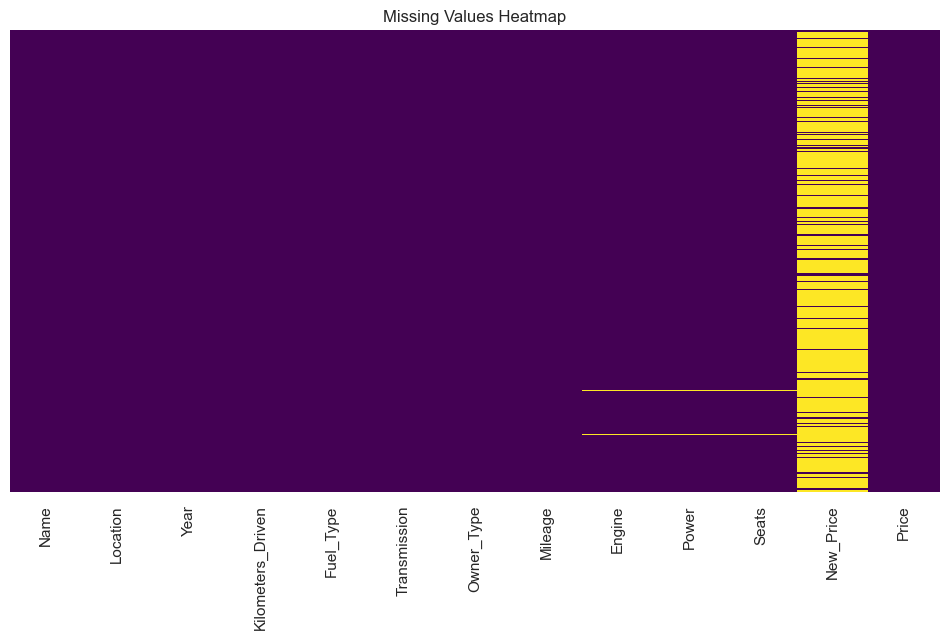

In [101]:
## Missing value analysis

plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [102]:
for col in train_df.columns:
    if train_df[col].isnull().sum()!=0:
        print(f"{col}: {train_df[col].isnull().sum()}:{round(train_df[col].isnull().mean()*100, 2)}%")

Mileage: 2:0.03%
Engine: 36:0.6%
Power: 36:0.6%
Seats: 42:0.7%
New_Price: 5195:86.31%


In [103]:
## New_Price column has 86% data missing, hence we are removing this column. 
train_df.drop(columns=['New_Price'], inplace=True)

In [104]:
train_df.describe(include='all')

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
count,6019,6019,6019.000000,6.019000e+03,6019,6019,6019,6017,5983,5983,5977.000000,6019.000000
unique,1876,11,NaN,NaN,5,2,4,442,146,372,NaN,NaN
top,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,18.9 kmpl,1197 CC,74 bhp,NaN,NaN
freq,49,790,NaN,NaN,3205,4299,4929,172,606,235,NaN,NaN
mean,NaN,NaN,2013.358199,5.873838e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.278735,9.479468
std,NaN,NaN,3.269742,9.126884e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.808840,11.187917
min,NaN,NaN,1998.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.440000
25%,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,3.500000
50%,NaN,NaN,2014.000000,5.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,5.640000
75%,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,9.950000


In [105]:
for col in train_df.columns:
    print(f"Column name {col}")
    print(f"Count: {train_df[col].nunique()}")
    print(f"{col}: {train_df[col].unique()}")
    print("=" * 50)

Column name Name
Count: 1876
Name: ['Maruti Wagon R LXI CNG' 'Hyundai Creta 1.6 CRDi SX Option'
 'Honda Jazz V' ... 'Volkswagen Polo IPL II 1.2 Petrol Highline'
 'Tata Bolt Revotron XT' 'Mahindra Xylo D4 BSIV']
Column name Location
Count: 11
Location: ['Mumbai' 'Pune' 'Chennai' 'Coimbatore' 'Hyderabad' 'Jaipur' 'Kochi'
 'Kolkata' 'Delhi' 'Bangalore' 'Ahmedabad']
Column name Year
Count: 22
Year: [2010 2015 2011 2012 2013 2016 2018 2014 2017 2007 2009 2008 2019 2006
 2005 2004 2002 2000 2003 1999 2001 1998]
Column name Kilometers_Driven
Count: 3093
Kilometers_Driven: [72000 41000 46000 ... 45004 70602 27365]
Column name Fuel_Type
Count: 5
Fuel_Type: ['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']
Column name Transmission
Count: 2
Transmission: ['Manual' 'Automatic']
Column name Owner_Type
Count: 4
Owner_Type: ['First' 'Second' 'Fourth & Above' 'Third']
Column name Mileage
Count: 442
Mileage: ['26.6 km/kg' '19.67 kmpl' '18.2 kmpl' '20.77 kmpl' '15.2 kmpl'
 '21.1 km/kg' '23.08 kmpl' '11.36 kmpl

In [106]:
for col in train_df.columns:
    if train_df[col].nunique() < 20:
        print(train_df[col].value_counts())
        print("==" * 50)

Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       535
Chennai       494
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64
Fuel_Type
Diesel      3205
Petrol      2746
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64
Transmission
Manual       4299
Automatic    1720
Name: count, dtype: int64
Owner_Type
First             4929
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64
Seats
5.0     5014
7.0      674
8.0      134
4.0       99
6.0       31
2.0       16
10.0       5
9.0        3
0.0        1
Name: count, dtype: int64


In [107]:
train_df.isnull().sum()

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64

In [108]:
train_df['Engine'].unique()

array(['998 CC', '1582 CC', '1199 CC', '1248 CC', '1968 CC', '814 CC',
       '1461 CC', '2755 CC', '1598 CC', '1462 CC', '1497 CC', '2179 CC',
       '2477 CC', '1498 CC', '2143 CC', '1995 CC', '1984 CC', '1197 CC',
       '2494 CC', '1798 CC', '2696 CC', '2698 CC', '1061 CC', '1198 CC',
       '2987 CC', '796 CC', '624 CC', '1999 CC', '1991 CC', '2694 CC',
       '1120 CC', '2498 CC', '799 CC', '2393 CC', '1399 CC', '1796 CC',
       '2148 CC', '1396 CC', '1950 CC', '4806 CC', '1998 CC', '1086 CC',
       '1193 CC', '2982 CC', '1493 CC', '2967 CC', '2993 CC', '1196 CC',
       '1799 CC', '2497 CC', '2354 CC', '1373 CC', '2996 CC', '1591 CC',
       '2894 CC', '5461 CC', '1595 CC', '936 CC', '1997 CC', nan,
       '1896 CC', '1390 CC', '1364 CC', '2199 CC', '993 CC', '999 CC',
       '1405 CC', '2956 CC', '1794 CC', '995 CC', '2496 CC', '1599 CC',
       '2400 CC', '1495 CC', '2523 CC', '793 CC', '4134 CC', '1596 CC',
       '1395 CC', '2953 CC', '1586 CC', '2362 CC', '1496 CC', '1368

In [109]:
import numpy as np

def extract_numeric(val):
    """
    Extract float from strings like: '1197 CC', '74.0 bhp', '23.1 kmpl', 'null bhp', NaN, None
    """
    try:
        result = float(str(val).strip().split()[0])
        return result
    except (ValueError, AttributeError):
        return np.nan

# Apply to both train and test
for col in ['Engine', 'Power', 'Mileage']:
    train_df[col] = train_df[col].apply(extract_numeric)
    test_df[col]  = test_df[col].apply(extract_numeric)

In [110]:
print(train_df[['Engine', 'Power', 'Mileage']].dtypes)
print(train_df[['Engine', 'Power', 'Mileage']].isnull().sum())

Engine     float64
Power      float64
Mileage    float64
dtype: object
Engine      36
Power      143
Mileage      2
dtype: int64


In [111]:

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
train_df[['Engine', 'Power', 'Mileage']] = imputer.fit_transform(train_df[['Engine', 'Power', 'Mileage']])

In [112]:
train_df['Seats'].unique()

array([ 5.,  7.,  8.,  4.,  6.,  2., nan, 10.,  9.,  0.])

In [113]:
train_df['Seats'] = train_df['Seats'].apply(extract_numeric)
test_df['Seats']  = test_df['Seats'].apply(extract_numeric)

In [114]:
train_df['Seats'].unique()

array([ 5.,  7.,  8.,  4.,  6.,  2., nan, 10.,  9.,  0.])

In [115]:
## Car canot have 0 seats. we will replace this nan
train_df['Seats'] = train_df['Seats'].replace(0, np.nan)
test_df['Seats']  = test_df['Seats'].replace(0, np.nan)

In [116]:
train_df['Seats'].fillna(train_df['Seats'].mode()[0], inplace=True)

In [117]:
train_df['Seats'].value_counts()

Seats
5.0     5057
7.0      674
8.0      134
4.0       99
6.0       31
2.0       16
10.0       5
9.0        3
Name: count, dtype: int64

In [118]:
numerical_features = train_df.select_dtypes(exclude=['object'])
categorical_features = train_df.select_dtypes(include=['object', 'category'])

In [119]:
numerical_features.columns

Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

In [120]:
categorical_features.columns

Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [121]:
for col in categorical_features.columns:
    if categorical_features[col].nunique() < 20:
        print(categorical_features[col].value_counts())
        print("==" * 50)

Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       535
Chennai       494
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64
Fuel_Type
Diesel      3205
Petrol      2746
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64
Transmission
Manual       4299
Automatic    1720
Name: count, dtype: int64
Owner_Type
First             4929
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64


### Step 2 - Fixing Incosistent formatting 

No issue with incosistent formatting in the data

In [122]:
### Looking at the above table there is no issue with data incosistencies or incosistent formatting with categorical columns
numerical_features.columns

Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

### Step 3 - Checking for duplicate values

In [123]:
train_df[train_df.duplicated()].sum()

Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage              0.0
Engine               0.0
Power                0.0
Seats                0.0
Price                0.0
dtype: object

#### Observation - There is no duplicate rows in the training data

### Step 4 - Correct data types

In [124]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6019 non-null   float64
 8   Engine             6019 non-null   float64
 9   Power              6019 non-null   float64
 10  Seats              6019 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 564.4+ KB


In [125]:
train_df['Year'].unique()

array([2010, 2015, 2011, 2012, 2013, 2016, 2018, 2014, 2017, 2007, 2009,
       2008, 2019, 2006, 2005, 2004, 2002, 2000, 2003, 1999, 2001, 1998])

### Step 5 - Outlier Treatment

In [126]:
train_df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,6019.000000,6.019000e+03,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,2013.358199,5.873838e+04,18.134966,1620.509221,112.883539,5.277621,9.479468
std,3.269742,9.126884e+04,4.581528,599.635458,53.283701,0.803479,11.187917
min,1998.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,0.440000
25%,2011.000000,3.400000e+04,15.170000,1198.000000,78.000000,5.000000,3.500000
50%,2014.000000,5.300000e+04,18.150000,1493.000000,97.700000,5.000000,5.640000
75%,2016.000000,7.300000e+04,21.100000,1969.000000,138.030000,5.000000,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,560.000000,10.000000,160.000000


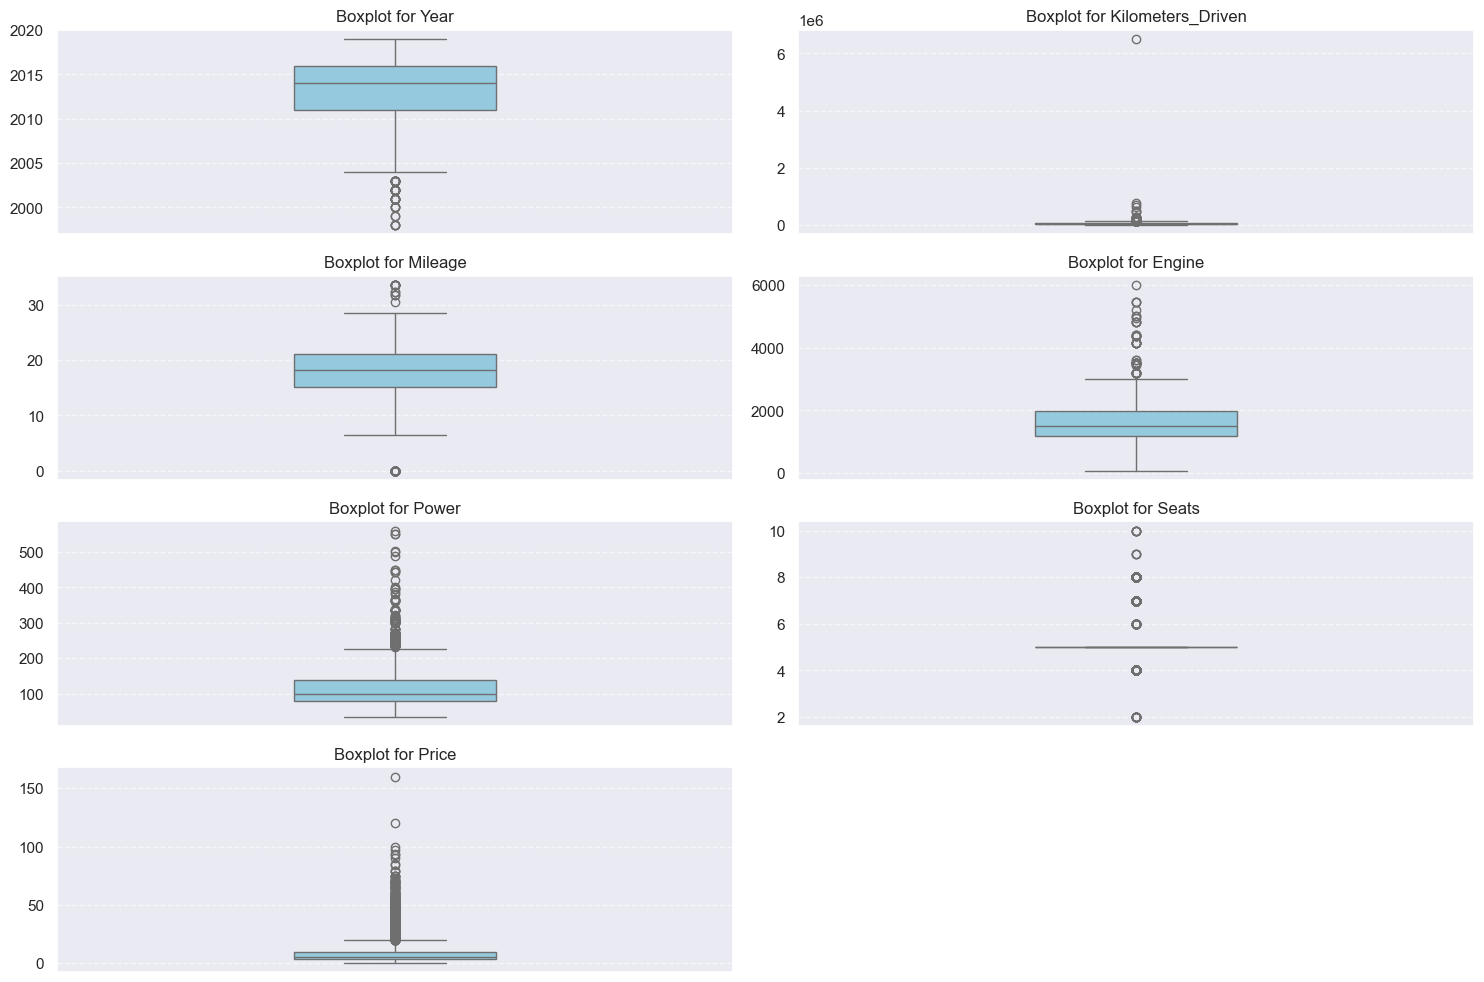

In [127]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(y=train_df[col], color='skyblue', width=0.3) 
    plt.title(f'Boxplot for {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [128]:
train_df.shape

(6019, 12)

In [129]:
# ## Count of outliers and lower and upper bound for numerical columns
# for col in numerical_features:
#     q1  = train_df[col].quantile(0.25)
#     q3  = train_df[col].quantile(0.75)
#     iqr = q3 - q1
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
#     outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
#     print(f"{col}: {len(outliers)} outliers | Lower: {lower:.2f} | Upper: {upper:.2f}")

In [130]:
# def replace_negatives_with_nan(df, cols):
#     df_clean = df.copy()
#     for col in cols:
#         negative_count = (df_clean[col] < 0).sum()
#         df_clean[col] = df_clean[col].apply(lambda x: np.nan if x < 0 else x)
#         print(f"{col}: {negative_count} negative value(s) replaced with NaN")
#     return df_clean

In [131]:
train_df.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [132]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,6019.0,2013.358199,3.269742,1998.00,2011.00,2014.00,2016.00,2019.00
Kilometers_Driven,6019.0,58738.380296,91268.843206,171.00,34000.00,53000.00,73000.00,6500000.00
Mileage,6019.0,18.134966,4.581528,0.00,15.17,18.15,21.10,33.54
Engine,6019.0,1620.509221,599.635458,72.00,1198.00,1493.00,1969.00,5998.00
Power,6019.0,112.883539,53.283701,34.20,78.00,97.70,138.03,560.00
Seats,6019.0,5.277621,0.803479,2.00,5.00,5.00,5.00,10.00
Price,6019.0,9.479468,11.187917,0.44,3.50,5.64,9.95,160.00


In [133]:
train_df['Power'].min()

34.2

In [134]:
def clip_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        q1  = df_clean[col].quantile(0.25)
        q3  = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        # CLIP instead of removing rows
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        print(f"{col}: clipped to [{lower:.2f}, {upper:.2f}]")
    
    return df_clean

In [135]:
cols_to_clip = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power']
train_df = clip_outliers_iqr(train_df, cols_to_clip)

Kilometers_Driven: clipped to [-24500.00, 131500.00]
Mileage: clipped to [6.27, 30.00]
Engine: clipped to [41.50, 3125.50]
Power: clipped to [-12.05, 228.07]


#### Univariate Analysis

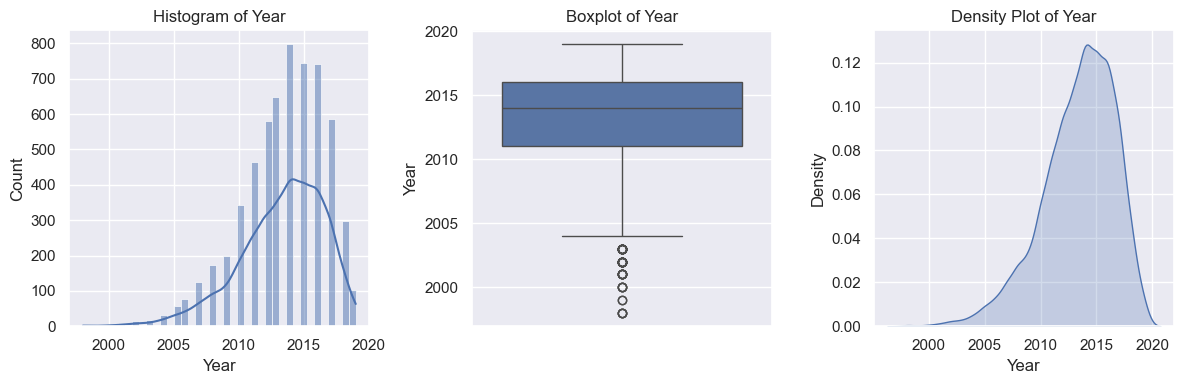

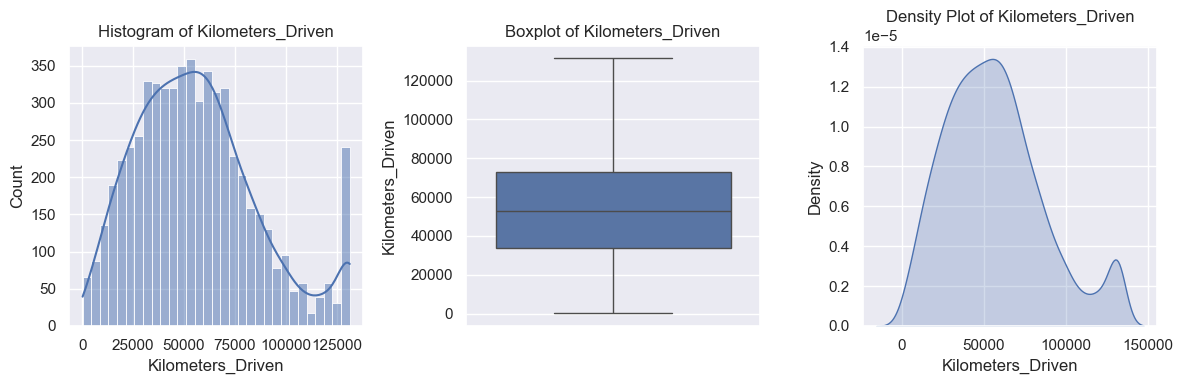

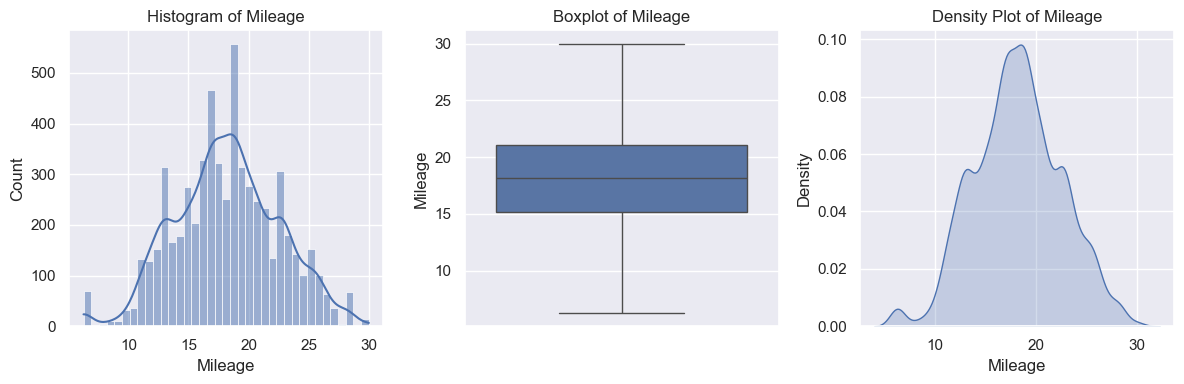

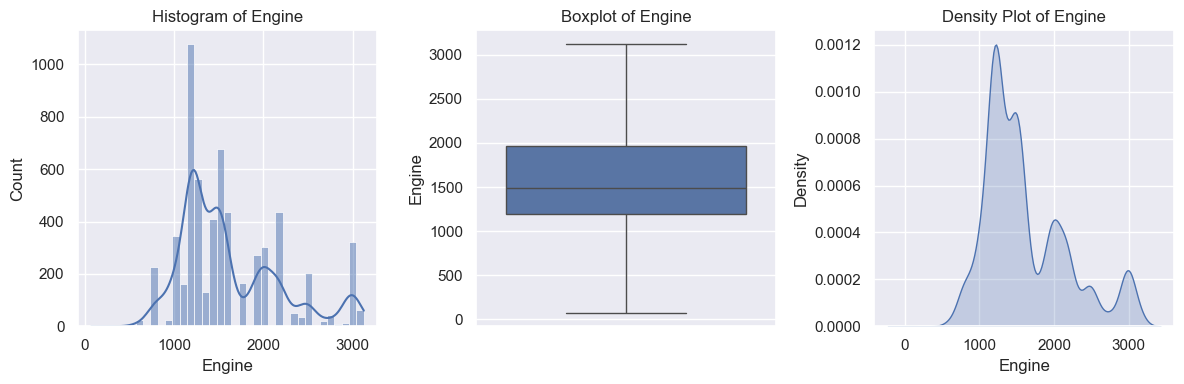

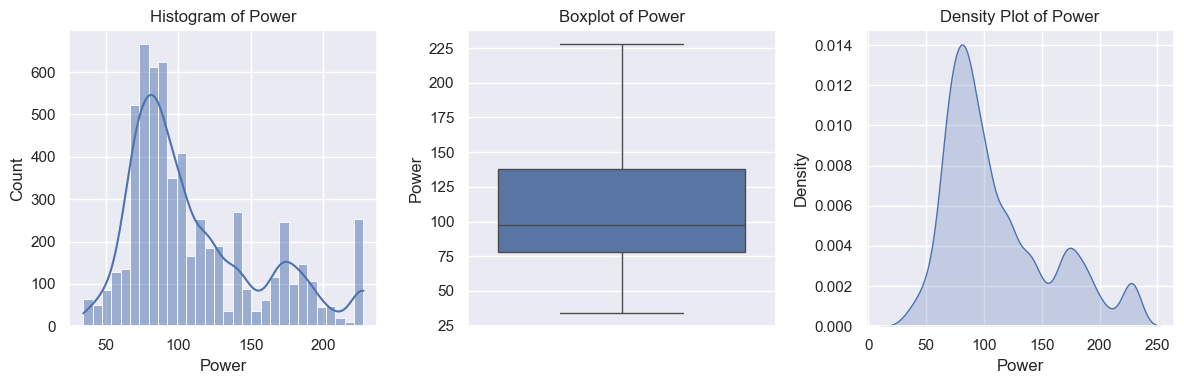

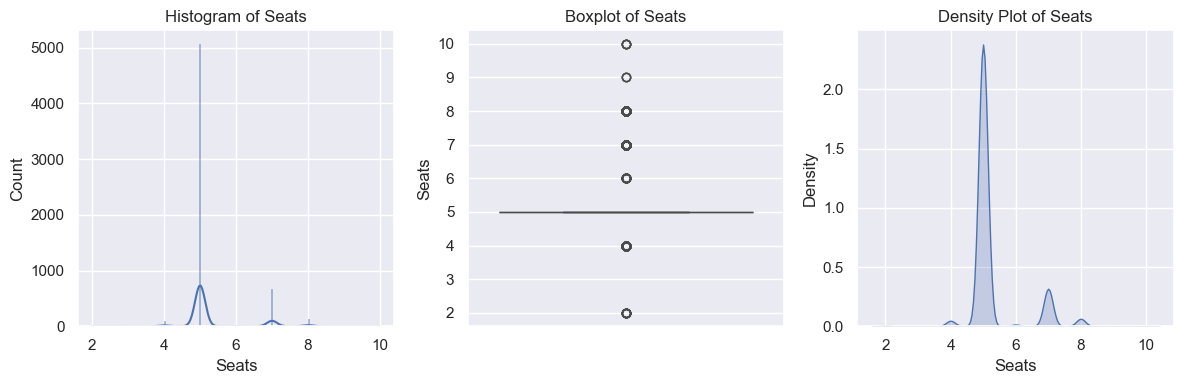

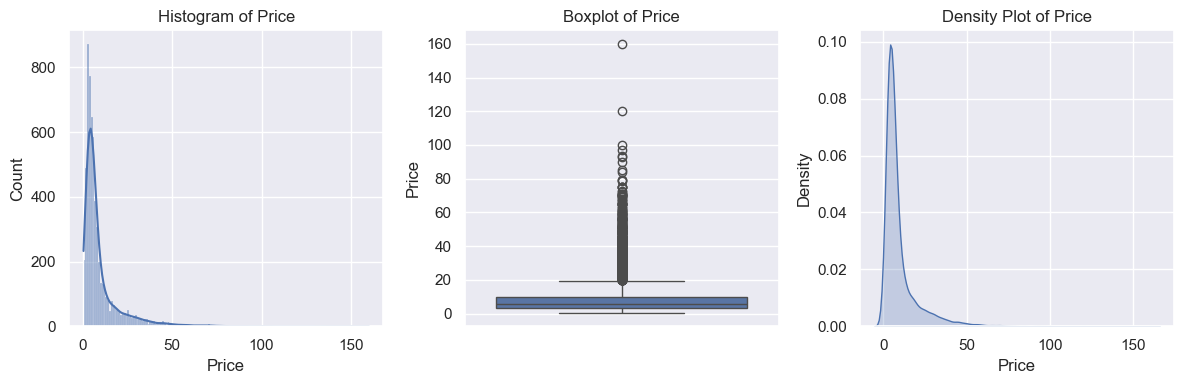

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
# histogram, boxplot, density plot for numerical columns
for col in numerical_features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=train_df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(train_df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()


 Frequency counts for Name:
 Name
Mahindra XUV500 W8 2WD           49
Maruti Swift VDI                 45
Honda City 1.5 S MT              34
Maruti Swift Dzire VDI           34
Maruti Swift VDI BSIV            31
                                 ..
Ford Fiesta Titanium 1.5 TDCi     1
Mahindra Scorpio S10 AT 4WD       1
Hyundai i20 1.2 Era               1
Toyota Camry W4 (AT)              1
Mahindra Xylo D4 BSIV             1
Name: count, Length: 1876, dtype: int64


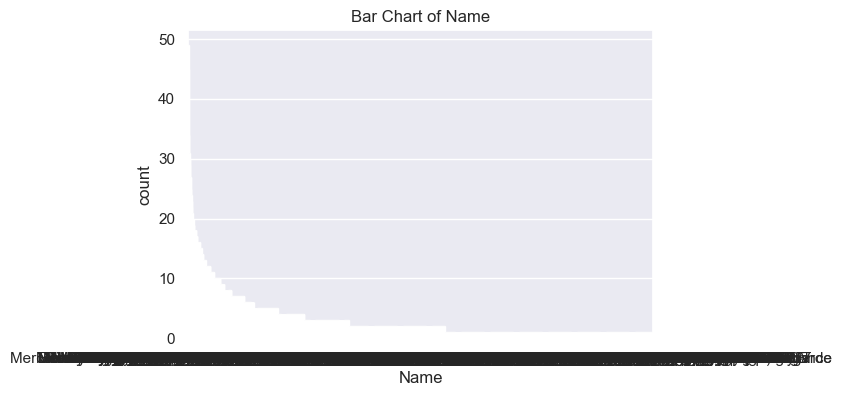


 Frequency counts for Location:
 Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       535
Chennai       494
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64


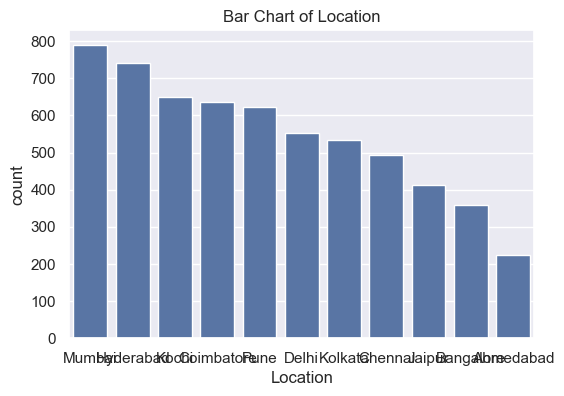


 Frequency counts for Fuel_Type:
 Fuel_Type
Diesel      3205
Petrol      2746
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64


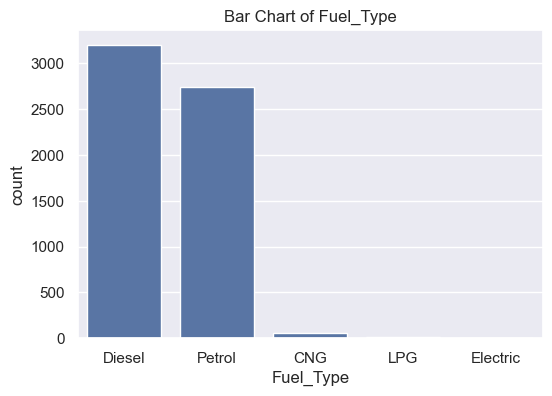


 Frequency counts for Transmission:
 Transmission
Manual       4299
Automatic    1720
Name: count, dtype: int64


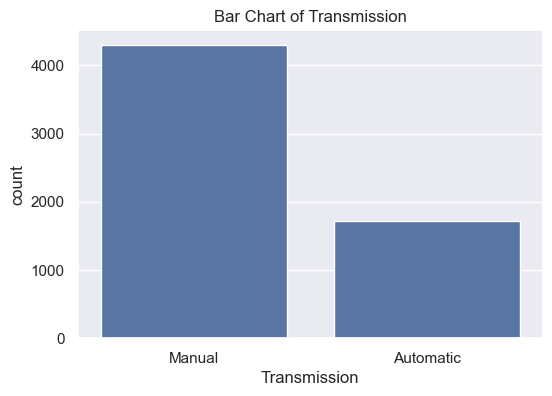


 Frequency counts for Owner_Type:
 Owner_Type
First             4929
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64


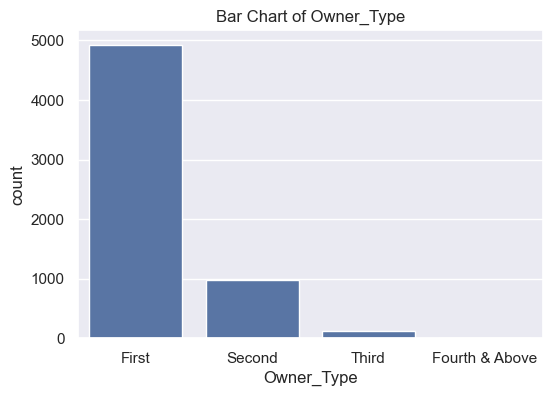

In [137]:
for index, col in enumerate(categorical_features):
    print(f"\n Frequency counts for {col}:\n", train_df[col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=train_df, order=train_df[col].value_counts().index)
    plt.title(f'Bar Chart of {col}')
    plt.show()

In [138]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6019 non-null   float64
 8   Engine             6019 non-null   float64
 9   Power              6019 non-null   float64
 10  Seats              6019 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 564.4+ KB


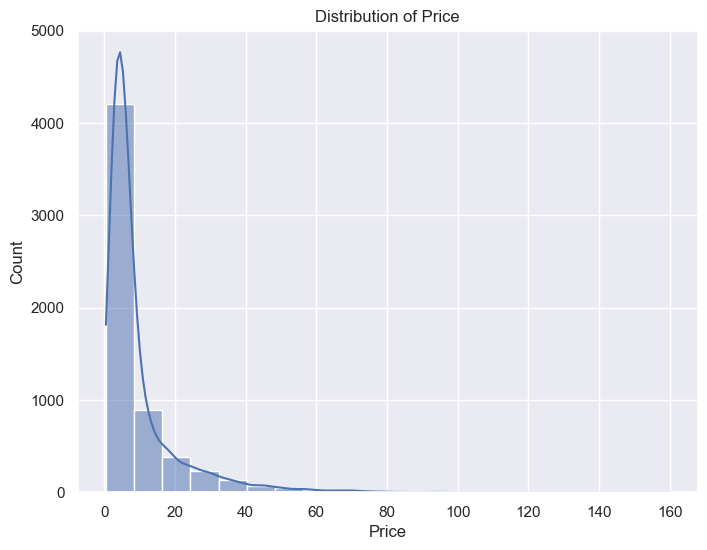

In [139]:
# Price Analysis
plt.figure(figsize=(8, 6))
sns.histplot(data=train_df['Price'], bins=20, kde=True)
plt.title('Distribution of Price')
plt.show()

## Bivariate analysis

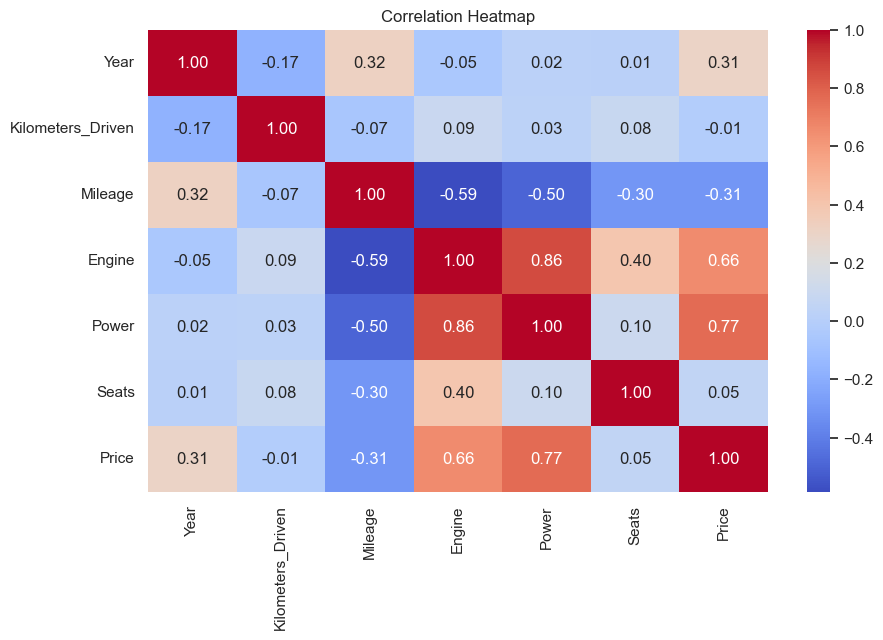

In [140]:
corr = numerical_features.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

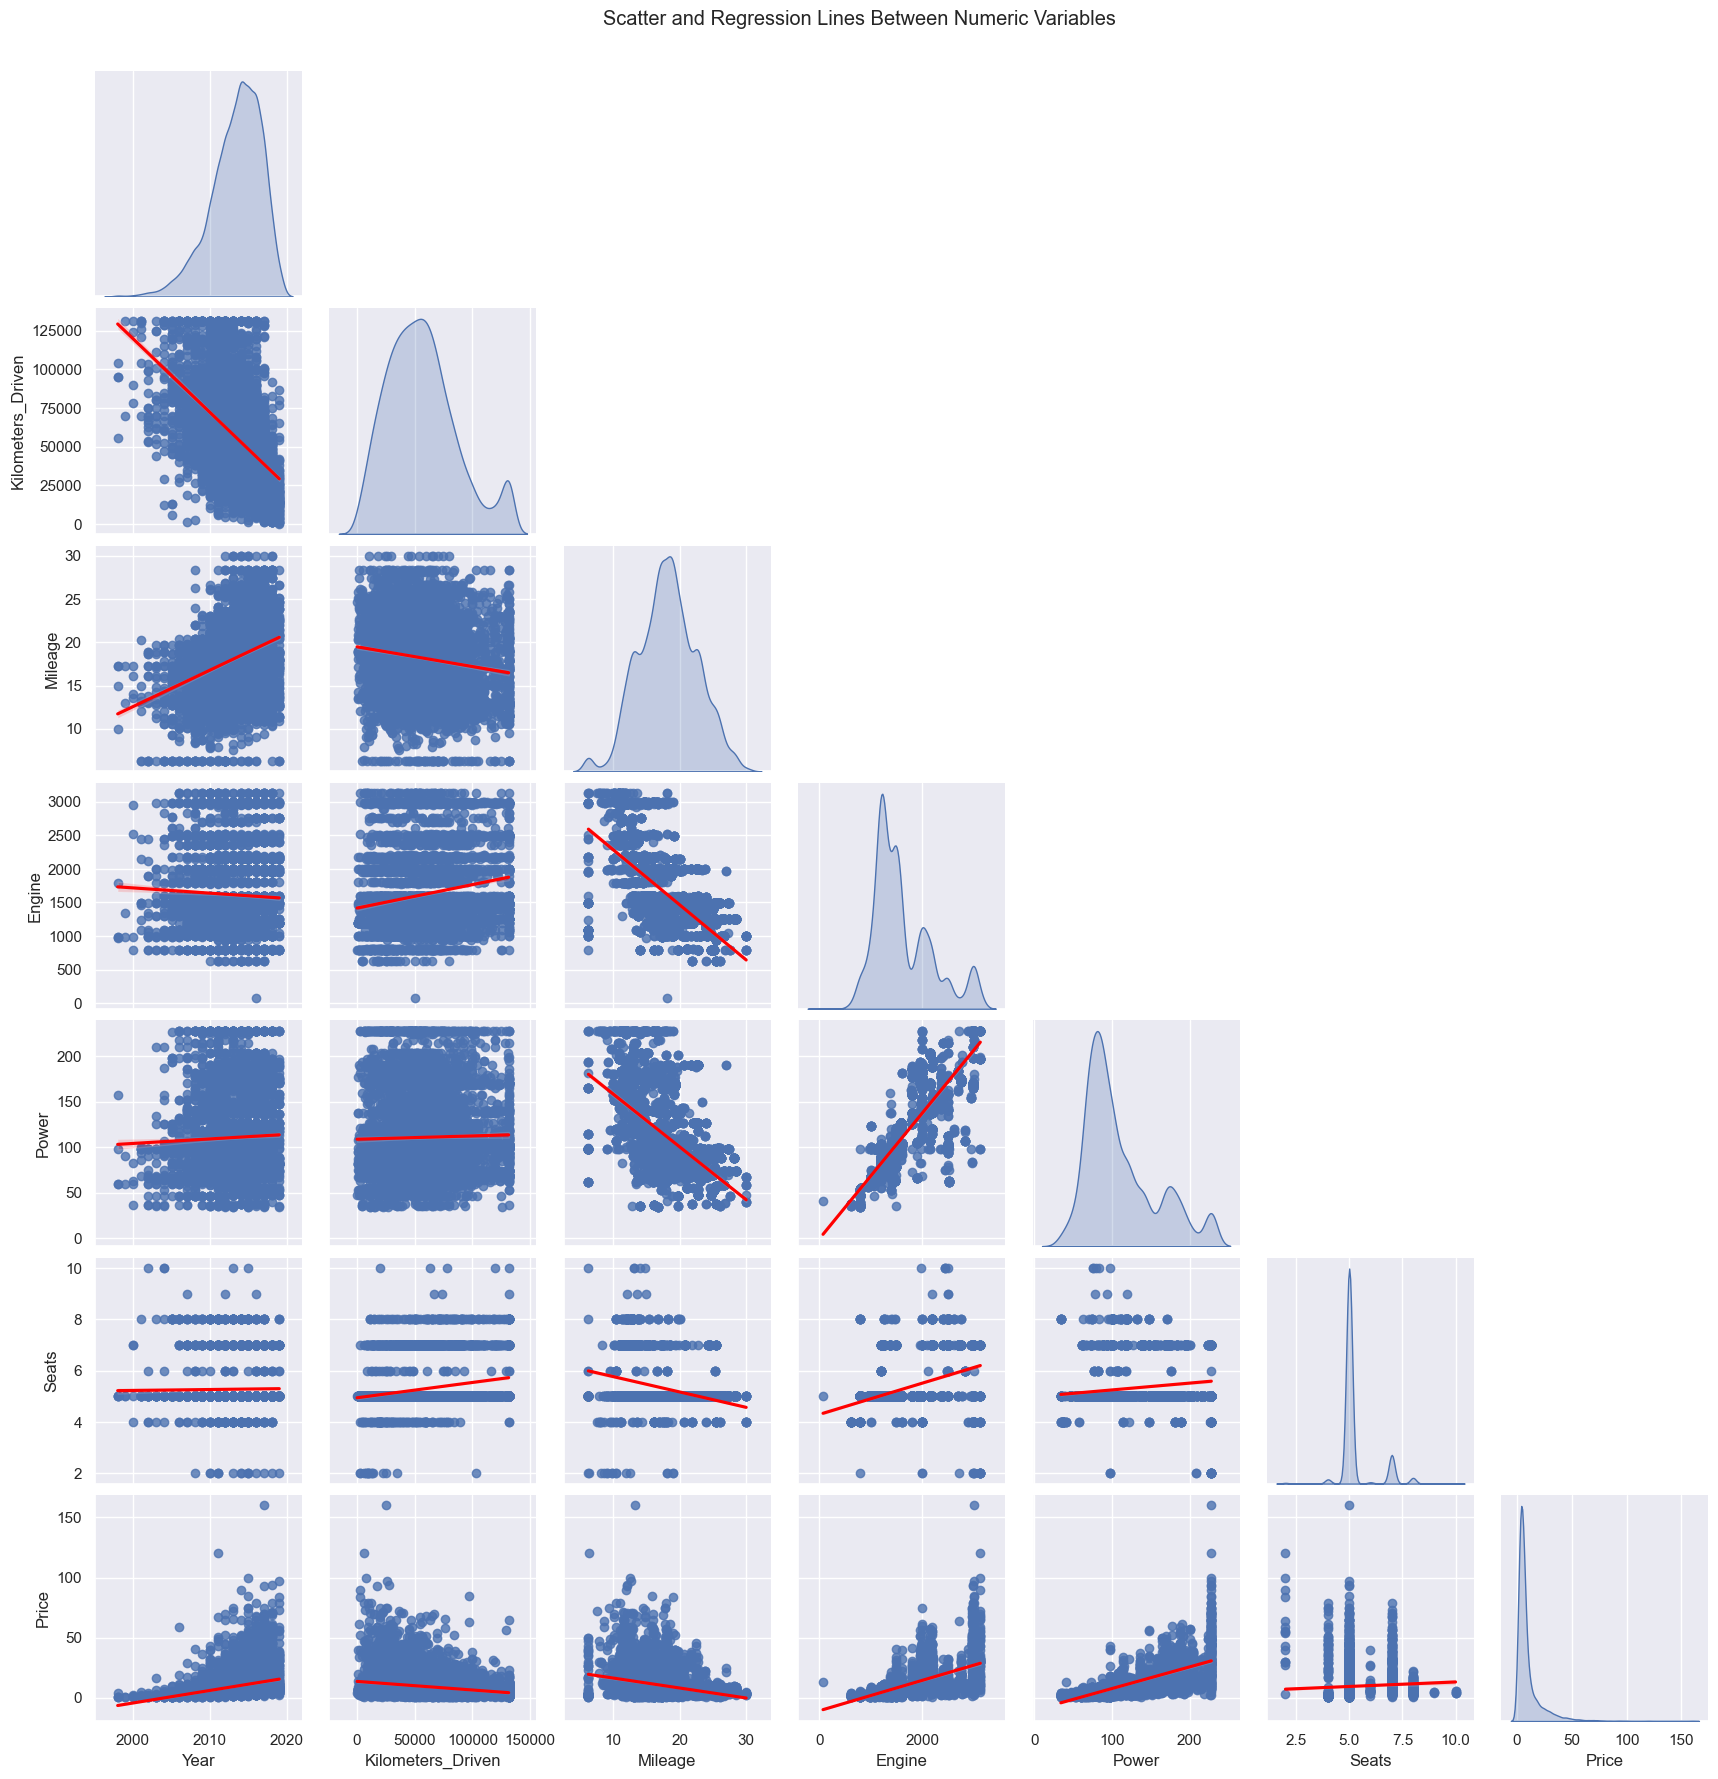

In [141]:
# Pairwise scatter plots + regression line
sns.pairplot(train_df, kind='reg', diag_kind='kde', corner=True, plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Scatter and Regression Lines Between Numeric Variables', y=1.02)
plt.show()

In [142]:
categorical_features

,Name,Location,Fuel_Type,Transmission,Owner_Type
0,Maruti Wagon R LXI CNG,Mumbai,CNG,Manual,First
1,Hyundai Creta 1.6 CRDi SX Option,Pune,Diesel,Manual,First
2,Honda Jazz V,Chennai,Petrol,Manual,First
3,Maruti Ertiga VDI,Chennai,Diesel,Manual,First
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,Diesel,Automatic,Second
...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,Diesel,Manual,First
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,Diesel,Manual,First
6016,Mahindra Xylo D4 BSIV,Jaipur,Diesel,Manual,Second
6017,Maruti Wagon R VXI,Kolkata,Petrol,Manual,First


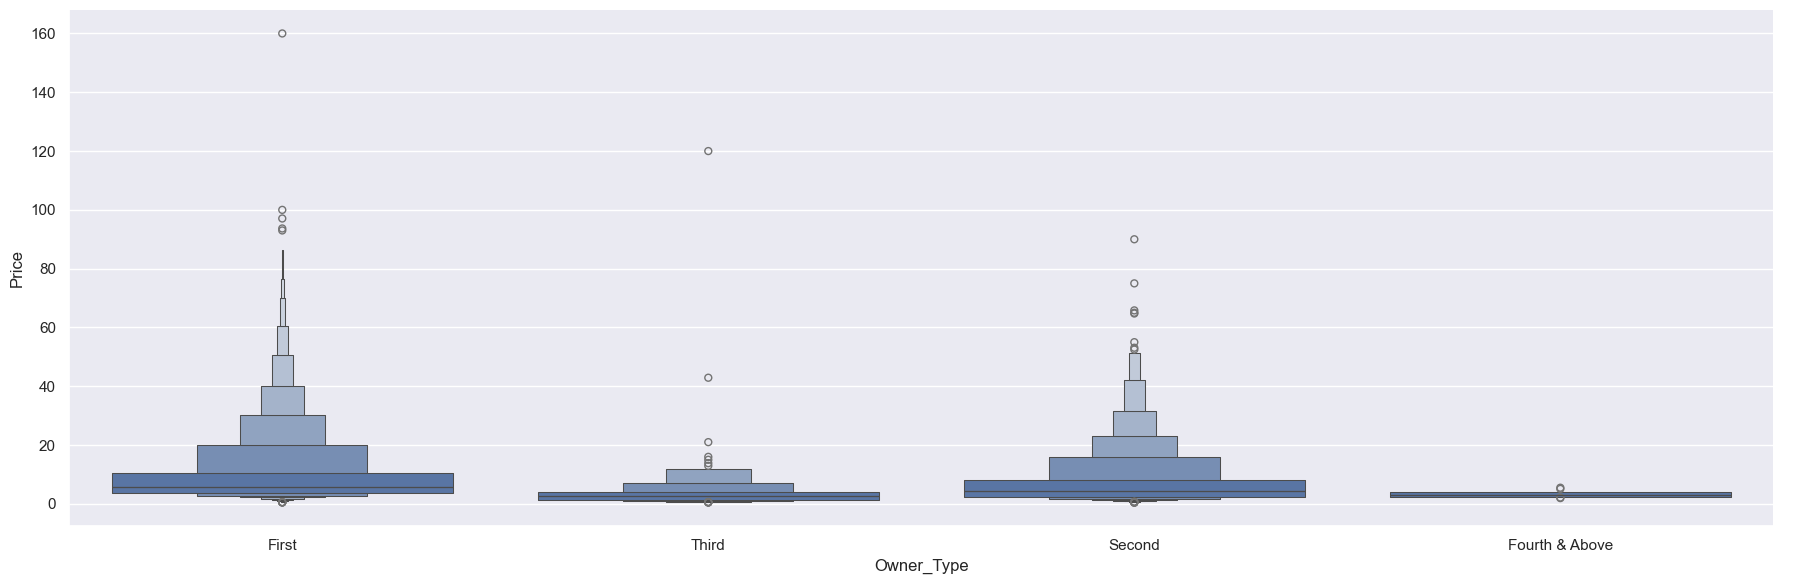

In [143]:
sns.catplot(y='Price',x='Owner_Type',data= train_df.sort_values('Price',ascending=False),kind="boxen",height=6, aspect=3)
plt.show()

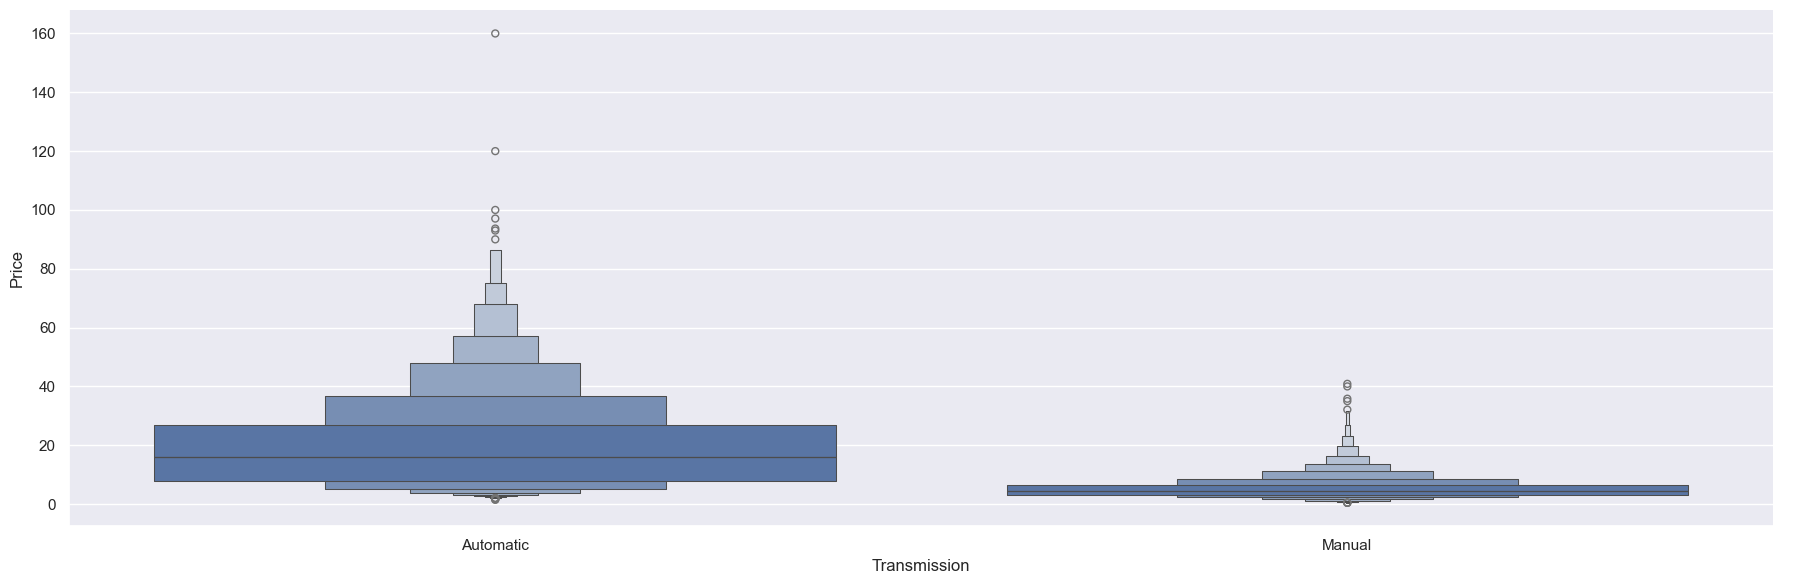

In [144]:
sns.catplot(y='Price',x='Transmission',data= train_df.sort_values('Price',ascending=False),kind="boxen",height=6, aspect=3)
plt.show()

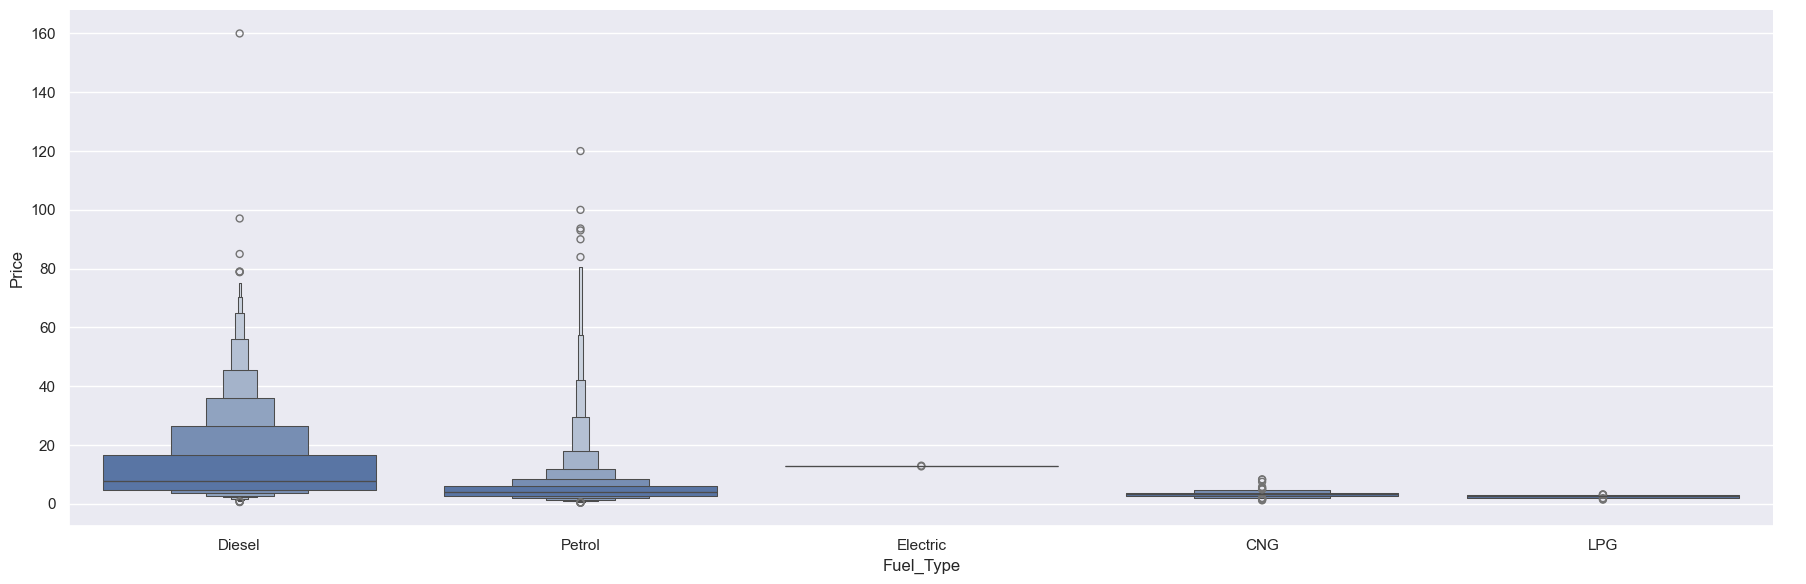

In [145]:
sns.catplot(y='Price',x='Fuel_Type',data= train_df.sort_values('Price',ascending=False),kind="boxen",height=6, aspect=3)
plt.show()

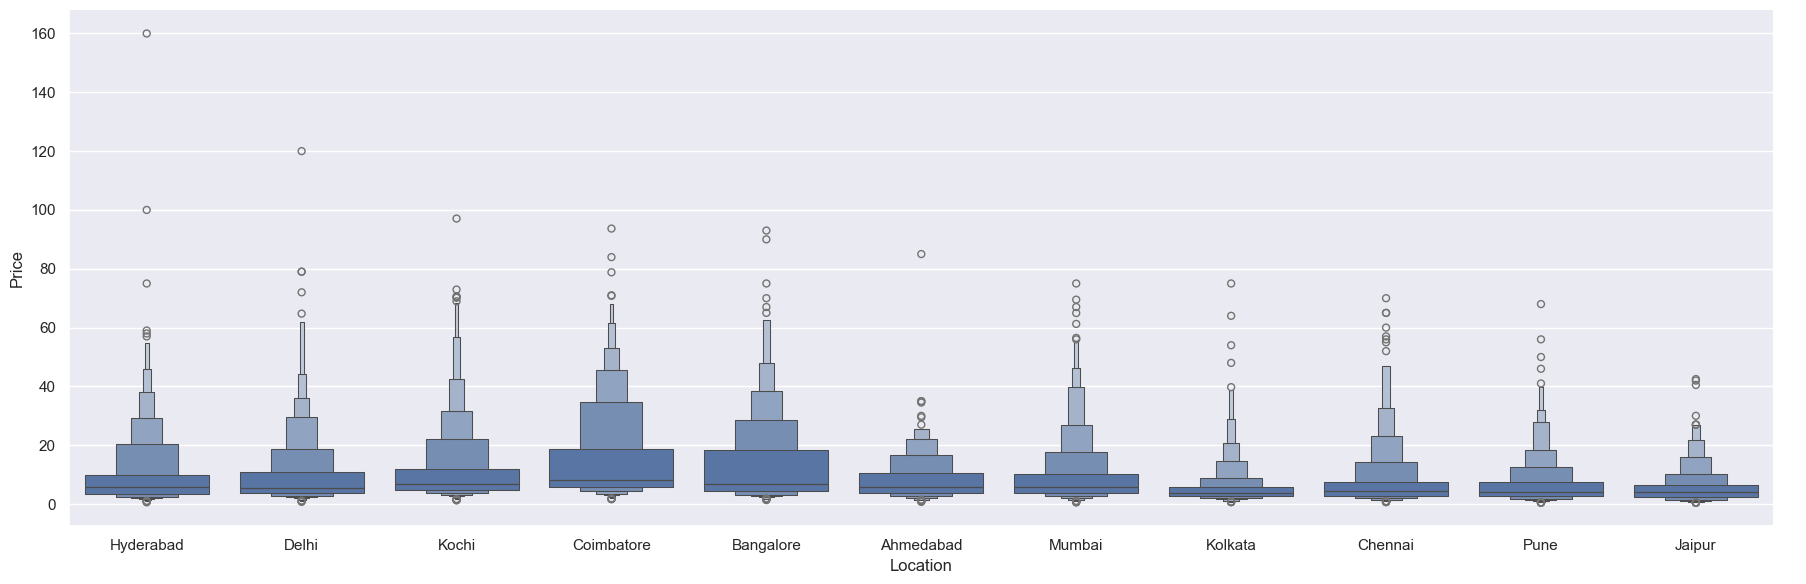

In [146]:
sns.catplot(y='Price',x='Location',data= train_df.sort_values('Price',ascending=False),kind="boxen",height=6, aspect=3)
plt.show()


For hadeling categorical data. We modtly use these 2 path:

* OneHotEncoder
* LabelEncoder

Where OneHotEncoder is used where data are not in any order and LabelEncoder when data is in order.

So, for each Features we will use plots to find out what to be used there.

### Multivariate Analysis

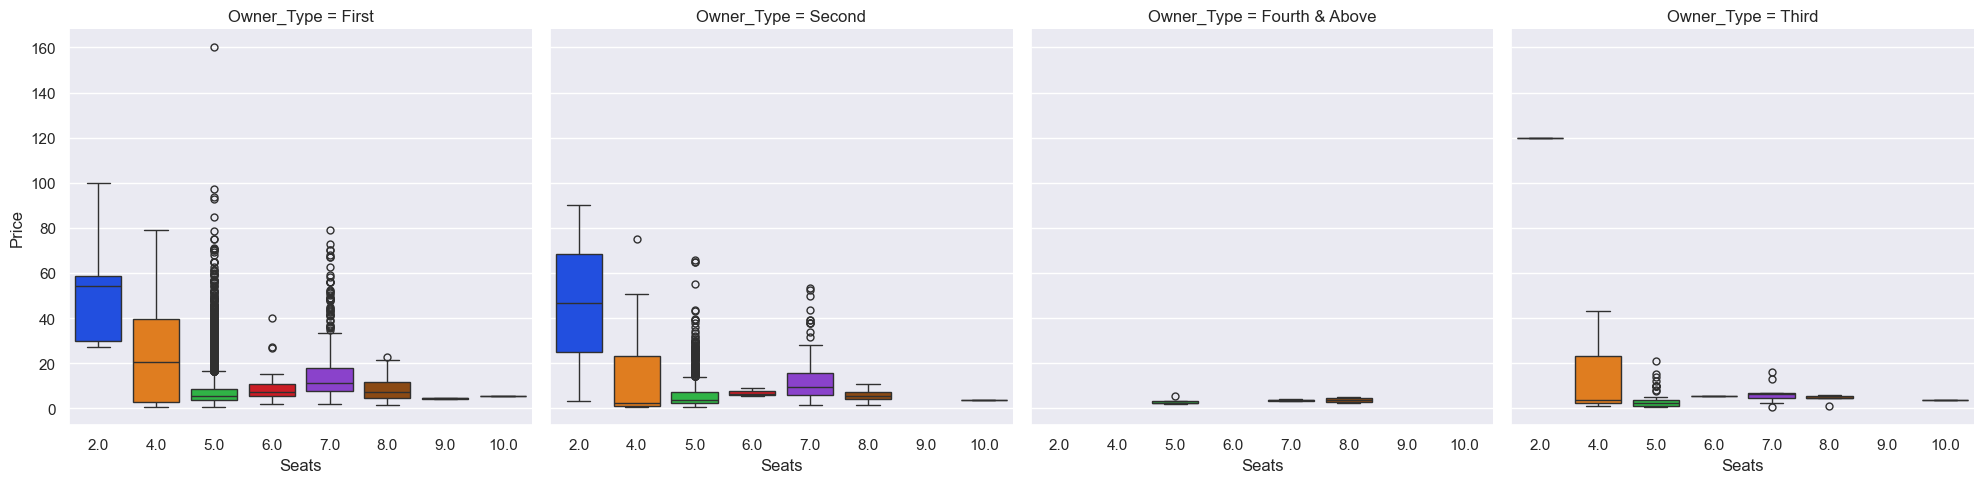

In [147]:
f = sns.catplot(x='Seats', y = 'Price', col='Owner_Type', col_wrap=4, data=train_df, kind='box',ci=False,
                   palette='bright', aspect=1)

In [148]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6019 non-null   float64
 8   Engine             6019 non-null   float64
 9   Power              6019 non-null   float64
 10  Seats              6019 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 564.4+ KB


### Feature Engineering

Creating new features from the existing features

In [149]:
train_df['Brand'] = train_df['Name'].apply(lambda x: x.split()[0])
train_df['Brand'].nunique()

31

In [150]:
train_df['Brand'].value_counts()

Brand
Maruti           1211
Hyundai          1107
Honda             608
Toyota            411
Mercedes-Benz     318
Volkswagen        315
Ford              300
Mahindra          272
BMW               267
Audi              236
Tata              186
Skoda             173
Renault           145
Chevrolet         121
Nissan             91
Land               60
Jaguar             40
Fiat               28
Mitsubishi         27
Mini               26
Volvo              21
Porsche            18
Jeep               15
Datsun             13
Force               3
ISUZU               2
Smart               1
Ambassador          1
Isuzu               1
Bentley             1
Lamborghini         1
Name: count, dtype: int64

In [151]:
train_df['Model'] = train_df['Name'].apply(lambda x: x.split()[1])
train_df['Model'].nunique()

212

In [152]:
train_df['Model'].value_counts()

Model
Swift         353
City          270
i20           247
Verna         170
Innova        164
             ... 
Beetle          1
Petra           1
Tiguan          1
Countryman      1
F               1
Name: count, Length: 212, dtype: int64

In [153]:
train_df['Year'].value_counts()

Year
2014    797
2015    744
2016    741
2013    649
2017    587
2012    580
2011    466
2010    342
2018    298
2009    198
2008    174
2007    125
2019    102
2006     78
2005     57
2004     31
2003     17
2002     15
2001      8
2000      4
1998      4
1999      2
Name: count, dtype: int64

In [154]:
train_df['Age'] = 2026 - train_df['Year']


<Axes: xlabel='Age', ylabel='Price'>

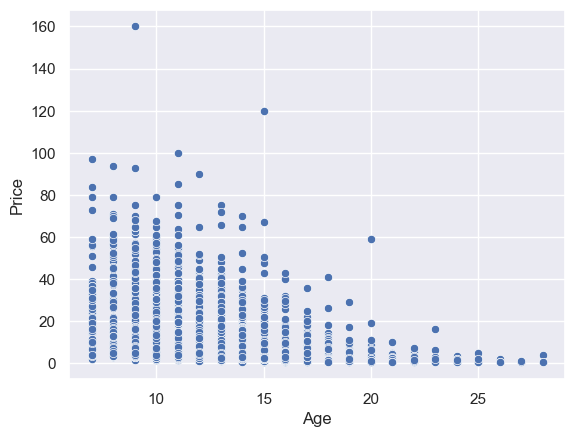

In [155]:
sns.scatterplot(data = train_df, x = 'Age', y = 'Price')


<Axes: xlabel='Age', ylabel='Count'>

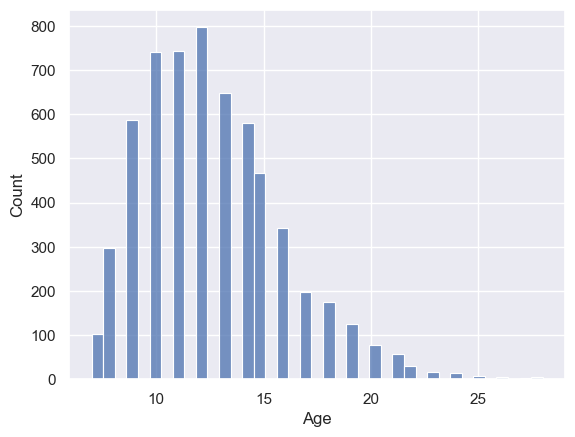

In [156]:
sns.histplot(data = train_df, x = 'Age')

### Dropping unwanted columns which are unrelated and do not contribute model prediction

In [157]:
train_df.drop(['Name','Kilometers_Driven','Mileage','Year'], axis=1 , inplace=True)

In [158]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      6019 non-null   object 
 1   Fuel_Type     6019 non-null   object 
 2   Transmission  6019 non-null   object 
 3   Owner_Type    6019 non-null   object 
 4   Engine        6019 non-null   float64
 5   Power         6019 non-null   float64
 6   Seats         6019 non-null   float64
 7   Price         6019 non-null   float64
 8   Brand         6019 non-null   object 
 9   Model         6019 non-null   object 
 10  Age           6019 non-null   int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 517.4+ KB


In [159]:
df_clean = train_df.copy()

In [160]:
train_df.columns

Index(['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine',
       'Power', 'Seats', 'Price', 'Brand', 'Model', 'Age'],
      dtype='object')

In [161]:
## Applying one hot encoder on Categorical columns
df_clean = pd.get_dummies(df_clean, columns=['Location','Fuel_Type','Transmission','Owner_Type','Brand', 'Model'], drop_first=True, dtype=int)


In [162]:
df_clean.head()

,Engine,Power,Seats,Price,Age,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,...,Model_Xcent,Model_Xenon,Model_Xylo,Model_Yeti,Model_Z4,Model_Zen,Model_Zest,Model_i10,Model_i20,Model_redi-GO
0,998.0,58.16,5.0,1.75,16,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1582.0,126.20,5.0,12.50,11,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1199.0,88.70,5.0,4.50,15,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1248.0,88.76,7.0,6.00,14,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1968.0,140.80,5.0,17.74,13,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [163]:
x = df_clean.drop( columns='Price', axis=1)
print(x.shape)

(6019, 263)


In [164]:
y = train_df['Price']
y.shape

(6019,)

In [165]:
# split the data into training and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [166]:
# Building Linear Regression Model
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(x_train, y_train)
y_pred_train = LR.predict(x_train)
y_pred_test = LR.predict(x_test)

In [167]:
from sklearn.metrics import r2_score
print(r2_score(y_train, y_pred_train))
print(r2_score(y_test, y_pred_test))

0.8573620181621852
0.800843728836552


In [168]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor()
rf_reg.fit(x_train, y_train)
y_pred= rf_reg.predict(x_test)
print("Accuracy on Traing set: ",rf_reg.score(x_train,y_train))
print("Accuracy on Testing set: ",rf_reg.score(x_test,y_test))

Accuracy on Traing set:  0.9839847507766186
Accuracy on Testing set:  0.8806562489705771


In [169]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=4)
xgb.fit(x_train, y_train)

# Evaluate
y_pred_xgb = xgb.predict(x_test)
print("Accuracy on Traing set: ",xgb.score(x_train,y_train))
print("Accuracy on Testing set: ",xgb.score(x_test,y_test))

Accuracy on Traing set:  0.9916889865428475
Accuracy on Testing set:  0.8676626096921363


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

# Evaluate
y_pred_dt = dt.predict(x_test)
print("Accuracy on Traing set: ",dt.score(x_train,y_train))
print("Accuracy on Testing set: ",dt.score(x_test,y_test))
print(f"R2 score : {r2_score(y_pred_dt, y_test)}")

Accuracy on Traing set:  0.9987528057278292
Accuracy on Testing set:  0.8202743197873212
R2 score : 0.8178081644890057


## Building Pipeline

In [186]:
import shap
import optuna
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df_clean.drop(['Price'], axis=1, errors='ignore')
y = df_clean['Price'] # Log Transform Target

categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numerical_cols = [c for c in X.columns if X[c].dtype in ['int64', 'float64']]

# Build the Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Optimize Hyperparameters with Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
    }

    # Create pipeline with trial parameters
    model = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', XGBRegressor(**params, n_jobs=-1))])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    return rmse

# Run Optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Train Final Model with Best Params
best_params = study.best_params
print("Best Parameters Found:", best_params)

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', XGBRegressor(**best_params))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_pipeline.fit(X_train, y_train)

print("Final Model Trained Successfully!")

[I 2026-04-19 14:07:03,818] A new study created in memory with name: no-name-df69d2b7-8fce-42fc-801b-041d843791c7
[I 2026-04-19 14:07:04,311] Trial 0 finished with value: 3.835512655634424 and parameters: {'n_estimators': 154, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 3}. Best is trial 0 with value: 3.835512655634424.
[I 2026-04-19 14:07:05,380] Trial 1 finished with value: 3.5190732066193005 and parameters: {'n_estimators': 421, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 13}. Best is trial 1 with value: 3.5190732066193005.
[I 2026-04-19 14:07:05,843] Trial 2 finished with value: 3.8539955990038823 and parameters: {'n_estimators': 138, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 14}. Best is trial 1 with value: 3.5190732066193005.
[I 2026-04-19 14:07:06,244] Trial 3 finished with value: 3.515372826594218 and parameters: {'n_estimators': 183, 'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 3 with value:

Best Parameters Found: {'n_estimators': 338, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 16}
Final Model Trained Successfully!


## Model Evaluation

In [187]:
# ─────────────────────────────────────────
# Evaluate on Test Set
# ─────────────────────────────────────────
y_pred = final_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE (log scale): {rmse:.4f}")
from sklearn.metrics import r2_score
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")

Test RMSE (log scale): 3.4921
Test R2 Score: 0.9009


## SHAP Analysis

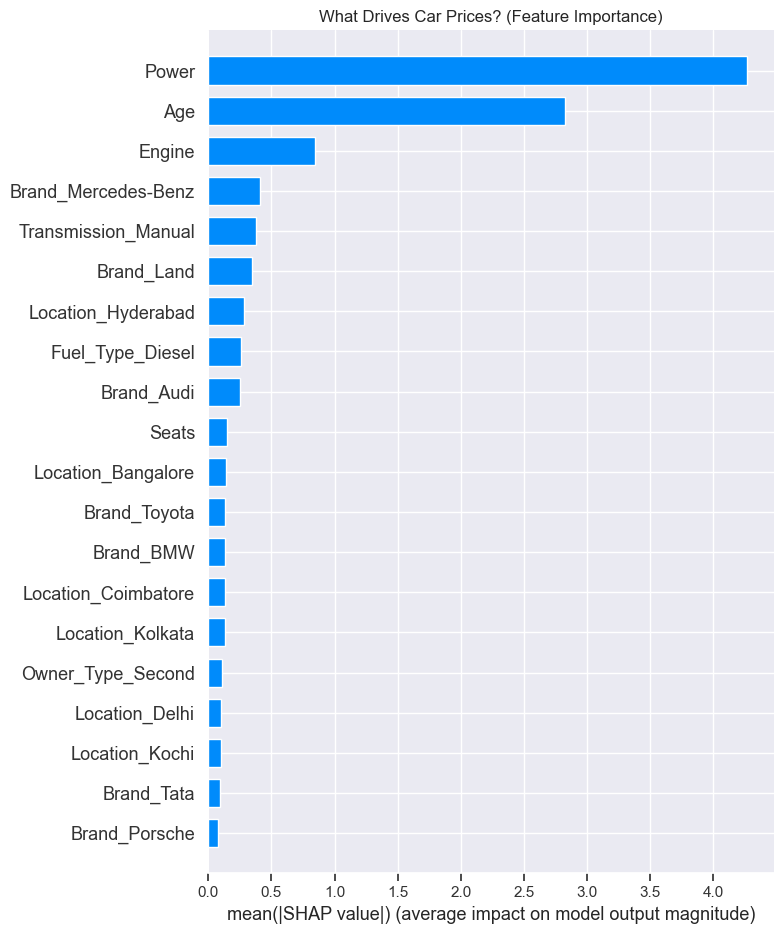

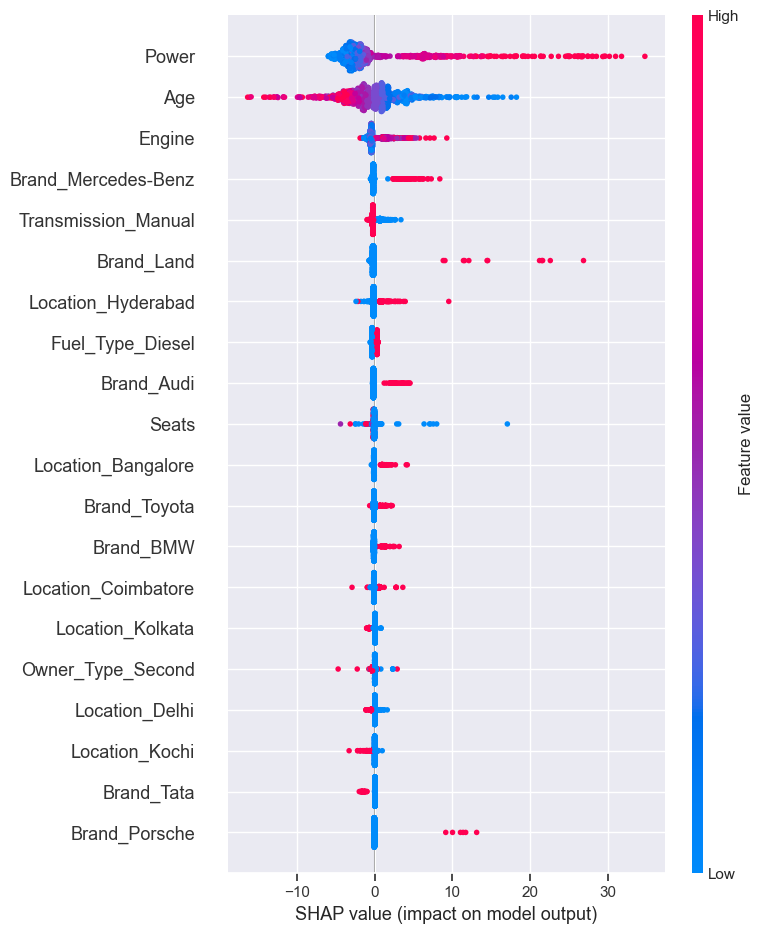

In [188]:
import shap
import matplotlib.pyplot as plt

preprocessor = final_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)

all_feature_names = [name.split("__", 1)[-1] for name in preprocessor.get_feature_names_out()]

xgb_model = final_pipeline.named_steps['regressor']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

plt.title("What Drives Car Prices? (Feature Importance)")
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, plot_type="bar")

plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)

In [173]:
import pickle
filename = 'car_price_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(final_pipeline, file)